Project FORESIGHT — Data Foundation & EDA

Objective:
Understand the structure, quality, and characteristics of the four
provided datasets before cleaning and modelling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
sales = pd.read_csv("../data/raw/sales_daily.csv")
sku = pd.read_csv("../data/raw/sku_master.csv")
calendar = pd.read_csv("../data/raw/calendar.csv")
inventory = pd.read_csv("../data/raw/inventory_snapshots.csv")

In [3]:
print("Sales:", sales.shape)
print("SKU Master:", sku.shape)
print("Calendar:", calendar.shape)
print("Inventory:", inventory.shape)

Sales: (36550, 6)
SKU Master: (50, 8)
Calendar: (731, 11)
Inventory: (4800, 8)


In [4]:
print("SALES COLUMNS")
print(sales.columns.tolist())

print("\nSKU MASTER COLUMNS")
print(sku.columns.tolist())

print("\nCALENDAR COLUMNS")
print(calendar.columns.tolist())

print("\nINVENTORY COLUMNS")
print(inventory.columns.tolist())

SALES COLUMNS
['Date', 'SKU', 'Units_Sold', 'Revenue', 'Price', 'Promotion']

SKU MASTER COLUMNS
['SKU', 'Product_Name', 'Category', 'Subcategory', 'Launch_Date', 'Cost_Price', 'Selling_Price', 'Gross_Margin_Per_Unit']

CALENDAR COLUMNS
['date', 'year', 'month', 'quarter', 'week', 'day_of_week', 'is_weekend', 'season', 'holiday', 'is_holiday', 'promotion_event']

INVENTORY COLUMNS
['Snapshot_Date', 'SKU', 'Current_Stock', 'On_Order', 'Lead_Time_Days', 'Safety_Stock', 'Reorder_Point', 'Inventory_Value']


In [5]:
print("SALES")
display(sales.head())

print("SKU MASTER")
display(sku.head())

print("CALENDAR")
display(calendar.head())

print("INVENTORY")
display(inventory.head())


SALES


,Date,SKU,Units_Sold,Revenue,Price,Promotion
0,2024-01-01,SKU001,5,18320.25,3664.05,0
1,2024-01-01,SKU002,15,57085.35,3805.69,0
2,2024-01-01,SKU003,5,40391.15,8078.23,0
3,2024-01-01,SKU004,5,34307.85,6861.57,0
4,2024-01-01,SKU005,12,113918.64,9493.22,0


SKU MASTER


,SKU,Product_Name,Category,Subcategory,Launch_Date,Cost_Price,Selling_Price,Gross_Margin_Per_Unit
0,SKU001,Product 001,Furniture,Chair,2022-04-09,1758.45,3664.05,1905.60
1,SKU002,Product 002,Home Decor,Table,2024-05-01,3867.09,3805.69,-61.40
2,SKU003,Product 003,Kitchen,Cushion,2023-12-22,589.48,8078.23,7488.75
3,SKU004,Product 004,Lighting,Cookware,2023-04-28,1445.74,6861.57,5415.83
4,SKU005,Product 005,Storage,Lamp,2023-04-22,5543.63,9493.22,3949.59


CALENDAR


,date,year,month,quarter,week,day_of_week,is_weekend,season,holiday,is_holiday,promotion_event
0,2024-01-01,2024,1,Q1,1,Monday,0,Winter,NaN,0,NaN
1,2024-01-02,2024,1,Q1,1,Tuesday,0,Winter,NaN,0,NaN
2,2024-01-03,2024,1,Q1,1,Wednesday,0,Winter,NaN,0,NaN
3,2024-01-04,2024,1,Q1,1,Thursday,0,Winter,NaN,0,NaN
4,2024-01-05,2024,1,Q1,1,Friday,0,Winter,NaN,0,NaN


INVENTORY


,Snapshot_Date,SKU,Current_Stock,On_Order,Lead_Time_Days,Safety_Stock,Reorder_Point,Inventory_Value
0,2024-01-01,SKU001,16,23,11,7,18,58420.96
1,2024-01-01,SKU002,29,12,4,5,10,163983.40
2,2024-01-01,SKU003,34,23,14,6,20,209060.22
3,2024-01-01,SKU004,34,4,7,5,12,42257.92
4,2024-01-01,SKU005,23,5,5,6,11,170945.89


In [6]:
# Missing values
print("MISSING VALUES")
print("\nSales:")
print(sales.isnull().sum())

print("\nSKU Master:")
print(sku.isnull().sum())

print("\nCalendar:")
print(calendar.isnull().sum())

print("\nInventory:")
print(inventory.isnull().sum())


# Duplicate rows
print("\n\nDUPLICATE ROWS")
print("Sales:", sales.duplicated().sum())
print("SKU Master:", sku.duplicated().sum())
print("Calendar:", calendar.duplicated().sum())
print("Inventory:", inventory.duplicated().sum())

MISSING VALUES

Sales:
Date          0
SKU           0
Units_Sold    0
Revenue       0
Price         0
Promotion     0
dtype: int64

SKU Master:
SKU                      0
Product_Name             0
Category                 0
Subcategory              0
Launch_Date              0
Cost_Price               0
Selling_Price            0
Gross_Margin_Per_Unit    0
dtype: int64

Calendar:
date                 0
year                 0
month                0
quarter              0
week                 0
day_of_week          0
is_weekend           0
season               0
holiday            723
is_holiday           0
promotion_event    656
dtype: int64

Inventory:
Snapshot_Date      0
SKU                0
Current_Stock      0
On_Order           0
Lead_Time_Days     0
Safety_Stock       0
Reorder_Point      0
Inventory_Value    0
dtype: int64


DUPLICATE ROWS
Sales: 0
SKU Master: 0
Calendar: 0
Inventory: 0


In [7]:
# Data types
print("DATA TYPES")

print("\nSales:")
print(sales.dtypes)

print("\nSKU Master:")
print(sku.dtypes)

print("\nCalendar:")
print(calendar.dtypes)

print("\nInventory:")
print(inventory.dtypes)

DATA TYPES

Sales:
Date              str
SKU               str
Units_Sold      int64
Revenue       float64
Price         float64
Promotion       int64
dtype: object

SKU Master:
SKU                          str
Product_Name                 str
Category                     str
Subcategory                  str
Launch_Date                  str
Cost_Price               float64
Selling_Price            float64
Gross_Margin_Per_Unit    float64
dtype: object

Calendar:
date                 str
year               int64
month              int64
quarter              str
week               int64
day_of_week          str
is_weekend         int64
season               str
holiday              str
is_holiday         int64
promotion_event      str
dtype: object

Inventory:
Snapshot_Date          str
SKU                    str
Current_Stock        int64
On_Order             int64
Lead_Time_Days       int64
Safety_Stock         int64
Reorder_Point        int64
Inventory_Value    float64
dtype: object


In [8]:
# Date ranges and SKU counts

sales["Date"] = pd.to_datetime(sales["Date"])
sku["Launch_Date"] = pd.to_datetime(sku["Launch_Date"])
calendar["date"] = pd.to_datetime(calendar["date"])
inventory["Snapshot_Date"] = pd.to_datetime(inventory["Snapshot_Date"])

print("DATE RANGES")

print("\nSales:")
print(sales["Date"].min(), "to", sales["Date"].max())

print("\nCalendar:")
print(calendar["date"].min(), "to", calendar["date"].max())

print("\nInventory:")
print(inventory["Snapshot_Date"].min(), "to", inventory["Snapshot_Date"].max())

print("\nSKU COUNTS")
print("Sales SKUs:", sales["SKU"].nunique())
print("Master SKUs:", sku["SKU"].nunique())
print("Inventory SKUs:", inventory["SKU"].nunique())

DATE RANGES

Sales:
2024-01-01 00:00:00 to 2025-12-31 00:00:00

Calendar:
2024-01-01 00:00:00 to 2025-12-31 00:00:00

Inventory:
2024-01-01 00:00:00 to 2025-12-01 00:00:00

SKU COUNTS
Sales SKUs: 50
Master SKUs: 50
Inventory SKUs: 200


In [9]:
# Check which inventory SKUs are not present in SKU Master

inventory_skus = set(inventory["SKU"].unique())
master_skus = set(sku["SKU"].unique())

extra_inventory_skus = inventory_skus - master_skus

print("Inventory SKUs:", len(inventory_skus))
print("Master SKUs:", len(master_skus))
print("Inventory SKUs not in SKU Master:", len(extra_inventory_skus))

print("\nExtra Inventory SKUs:")
print(sorted(extra_inventory_skus))

Inventory SKUs: 200
Master SKUs: 50
Inventory SKUs not in SKU Master: 150

Extra Inventory SKUs:
['SKU051', 'SKU052', 'SKU053', 'SKU054', 'SKU055', 'SKU056', 'SKU057', 'SKU058', 'SKU059', 'SKU060', 'SKU061', 'SKU062', 'SKU063', 'SKU064', 'SKU065', 'SKU066', 'SKU067', 'SKU068', 'SKU069', 'SKU070', 'SKU071', 'SKU072', 'SKU073', 'SKU074', 'SKU075', 'SKU076', 'SKU077', 'SKU078', 'SKU079', 'SKU080', 'SKU081', 'SKU082', 'SKU083', 'SKU084', 'SKU085', 'SKU086', 'SKU087', 'SKU088', 'SKU089', 'SKU090', 'SKU091', 'SKU092', 'SKU093', 'SKU094', 'SKU095', 'SKU096', 'SKU097', 'SKU098', 'SKU099', 'SKU100', 'SKU101', 'SKU102', 'SKU103', 'SKU104', 'SKU105', 'SKU106', 'SKU107', 'SKU108', 'SKU109', 'SKU110', 'SKU111', 'SKU112', 'SKU113', 'SKU114', 'SKU115', 'SKU116', 'SKU117', 'SKU118', 'SKU119', 'SKU120', 'SKU121', 'SKU122', 'SKU123', 'SKU124', 'SKU125', 'SKU126', 'SKU127', 'SKU128', 'SKU129', 'SKU130', 'SKU131', 'SKU132', 'SKU133', 'SKU134', 'SKU135', 'SKU136', 'SKU137', 'SKU138', 'SKU139', 'SKU140', 'S

In [10]:
# Check number of inventory records per SKU

inventory_sku_counts = inventory.groupby("SKU").size()

print(inventory_sku_counts.describe())

print("\nSKUs with more than 24 records:")
print(inventory_sku_counts[inventory_sku_counts > 24])

count    200.0
mean      24.0
std        0.0
min       24.0
25%       24.0
50%       24.0
75%       24.0
max       24.0
dtype: float64

SKUs with more than 24 records:
Series([], dtype: int64)


In [11]:
# Detailed data quality summary

datasets = {
    "Sales": sales,
    "SKU Master": sku,
    "Calendar": calendar,
    "Inventory": inventory
}

for name, df in datasets.items():
    print("\n" + "="*50)
    print(name)
    print("="*50)
    
    print("Rows:", len(df))
    print("Columns:", len(df.columns))
    print("Duplicate rows:", df.duplicated().sum())
    
    print("\nMissing values:")
    print(df.isnull().sum())


Sales
Rows: 36550
Columns: 6
Duplicate rows: 0

Missing values:
Date          0
SKU           0
Units_Sold    0
Revenue       0
Price         0
Promotion     0
dtype: int64

SKU Master
Rows: 50
Columns: 8
Duplicate rows: 0

Missing values:
SKU                      0
Product_Name             0
Category                 0
Subcategory              0
Launch_Date              0
Cost_Price               0
Selling_Price            0
Gross_Margin_Per_Unit    0
dtype: int64

Calendar
Rows: 731
Columns: 11
Duplicate rows: 0

Missing values:
date                 0
year                 0
month                0
quarter              0
week                 0
day_of_week          0
is_weekend           0
season               0
holiday            723
is_holiday           0
promotion_event    656
dtype: int64

Inventory
Rows: 4800
Columns: 8
Duplicate rows: 0

Missing values:
Snapshot_Date      0
SKU                0
Current_Stock      0
On_Order           0
Lead_Time_Days     0
Safety_Stock       0
Reo

In [12]:
# Check important numeric columns for unusual values

print("SALES NUMERIC CHECKS")
print("Units sold < 0:", (sales["Units_Sold"] < 0).sum())
print("Revenue < 0:", (sales["Revenue"] < 0).sum())
print("Price <= 0:", (sales["Price"] <= 0).sum())

print("\nSKU MASTER NUMERIC CHECKS")
print("Cost price <= 0:", (sku["Cost_Price"] <= 0).sum())
print("Selling price <= 0:", (sku["Selling_Price"] <= 0).sum())

print("\nINVENTORY NUMERIC CHECKS")
print("Current stock < 0:", (inventory["Current_Stock"] < 0).sum())
print("On order < 0:", (inventory["On_Order"] < 0).sum())
print("Lead time < 0:", (inventory["Lead_Time_Days"] < 0).sum())
print("Safety stock < 0:", (inventory["Safety_Stock"] < 0).sum())
print("Reorder point < 0:", (inventory["Reorder_Point"] < 0).sum())

SALES NUMERIC CHECKS
Units sold < 0: 0
Revenue < 0: 0
Price <= 0: 0

SKU MASTER NUMERIC CHECKS
Cost price <= 0: 0
Selling price <= 0: 0

INVENTORY NUMERIC CHECKS
Current stock < 0: 0
On order < 0: 0
Lead time < 0: 0
Safety stock < 0: 0
Reorder point < 0: 0


In [13]:
# Compare Inventory SKUs with Sales SKUs

sales_skus = set(sales["SKU"].unique())
inventory_skus = set(inventory["SKU"].unique())

inventory_not_in_sales = inventory_skus - sales_skus
sales_not_in_inventory = sales_skus - inventory_skus

print("Inventory SKUs not in Sales:", len(inventory_not_in_sales))
print("Sales SKUs not in Inventory:", len(sales_not_in_inventory))

print("\nFirst 20 inventory-only SKUs:")
print(sorted(inventory_not_in_sales)[:20])

Inventory SKUs not in Sales: 150
Sales SKUs not in Inventory: 0

First 20 inventory-only SKUs:
['SKU051', 'SKU052', 'SKU053', 'SKU054', 'SKU055', 'SKU056', 'SKU057', 'SKU058', 'SKU059', 'SKU060', 'SKU061', 'SKU062', 'SKU063', 'SKU064', 'SKU065', 'SKU066', 'SKU067', 'SKU068', 'SKU069', 'SKU070']


In [14]:
# Check inventory records for the valid 50 SKUs vs extra 150 SKUs

valid_inventory = inventory[inventory["SKU"].isin(sales_skus)]
extra_inventory = inventory[~inventory["SKU"].isin(sales_skus)]

print("Records for Sales SKUs:", len(valid_inventory))
print("Records for extra SKUs:", len(extra_inventory))

print("\nValid inventory date range:")
print(valid_inventory["Snapshot_Date"].min(), "to", valid_inventory["Snapshot_Date"].max())

print("\nExtra inventory date range:")
print(extra_inventory["Snapshot_Date"].min(), "to", extra_inventory["Snapshot_Date"].max())

Records for Sales SKUs: 1200
Records for extra SKUs: 3600

Valid inventory date range:
2024-01-01 00:00:00 to 2025-12-01 00:00:00

Extra inventory date range:
2024-01-01 00:00:00 to 2025-12-01 00:00:00


## Data Quality Findings

### Sales
- 36,550 records covering January 2024 to December 2025.
- 50 unique SKUs.
- No missing values.
- No duplicate records.
- No negative units sold or revenue values.
- No zero or negative prices.

### SKU Master
- 50 SKU records.
- No missing values.
- No duplicate records.
- Cost price and selling price contain no zero or negative values.

### Calendar
- 731 daily records covering January 2024 to December 2025.
- No duplicate records.
- `holiday` contains missing values on dates without a recorded holiday.
- `promotion_event` contains missing values on dates without a recorded promotion event.

### Inventory
- 4,800 records covering January 2024 to December 2025.
- 200 unique SKUs.
- No missing values.
- No duplicate records.
- No negative inventory, order, lead-time, safety-stock, or reorder-point values.

### Cross-Dataset SKU Issue
- Sales and SKU Master contain 50 SKUs.
- Inventory contains 200 SKUs.
- All 50 Sales SKUs are present in Inventory.
- 150 Inventory SKUs (`SKU051`–`SKU200`) have no corresponding Sales or SKU Master records.
- Each Inventory SKU has 24 monthly snapshots.
- The additional 150 SKUs therefore represent inventory records without corresponding product/sales information.

### Cleaning Decision
The 150 unmatched Inventory SKUs will be excluded from the modelling dataset because they cannot be linked to the SKU Master or Sales history required for SKU-level demand forecasting.

The original raw Inventory data will be retained unchanged. The exclusion will be performed through the reproducible data-processing pipeline and documented as a data-quality handling decision.

In [15]:
sales = pd.read_csv("../data/processed/sales_daily_clean.csv")
sku = pd.read_csv("../data/processed/sku_master_clean.csv")
calendar = pd.read_csv("../data/processed/calendar_clean.csv")
inventory = pd.read_csv("../data/processed/inventory_snapshots_clean.csv")

sales["Date"] = pd.to_datetime(sales["Date"])
sku["Launch_Date"] = pd.to_datetime(sku["Launch_Date"])
calendar["date"] = pd.to_datetime(calendar["date"])
inventory["Snapshot_Date"] = pd.to_datetime(inventory["Snapshot_Date"])

print("Processed data loaded successfully.")
print("Sales:", sales.shape)
print("SKU Master:", sku.shape)
print("Calendar:", calendar.shape)
print("Inventory:", inventory.shape)

Processed data loaded successfully.
Sales: (36550, 6)
SKU Master: (50, 8)
Calendar: (731, 11)
Inventory: (1200, 8)


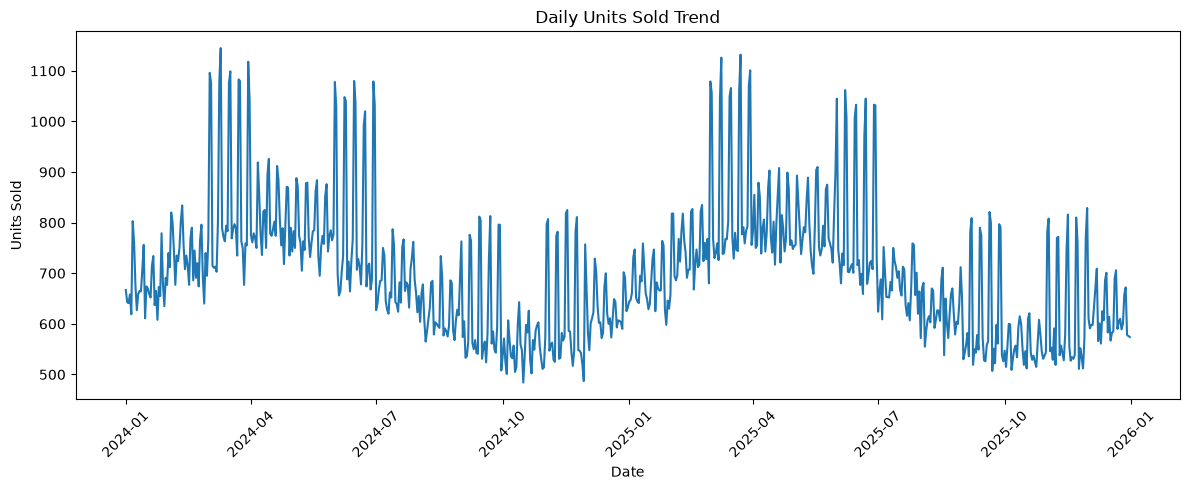

In [16]:
daily_sales = (
    sales.groupby("Date")["Units_Sold"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(12, 5))
plt.plot(daily_sales["Date"], daily_sales["Units_Sold"])
plt.title("Daily Units Sold Trend")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

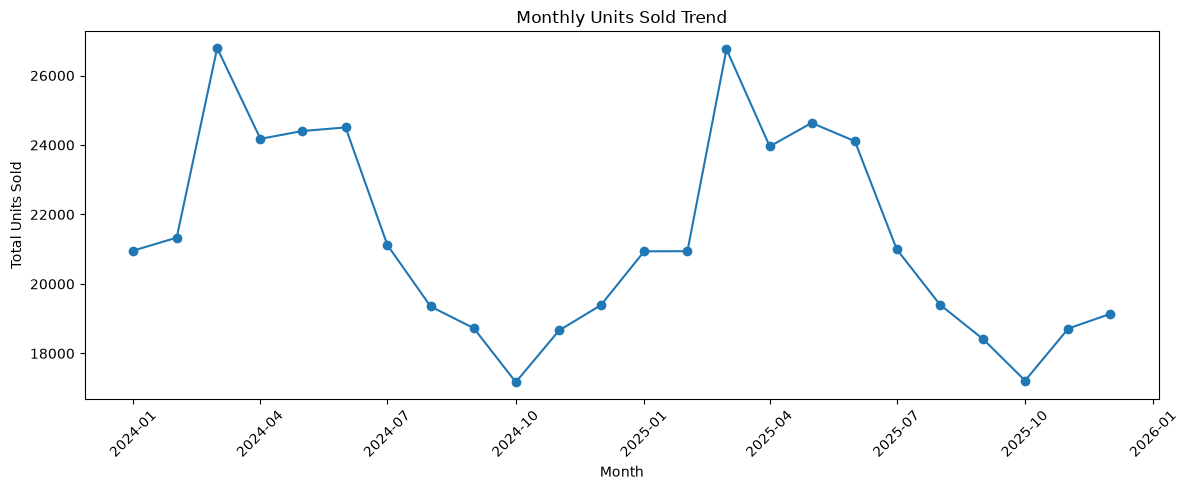

TOP 5 MONTHS BY DEMAND
      Date  Units_Sold
2024-03-01       26791
2025-03-01       26757
2025-05-01       24636
2024-06-01       24506
2024-05-01       24402

LOWEST 5 MONTHS BY DEMAND
      Date  Units_Sold
2024-10-01       17173
2025-10-01       17217
2025-09-01       18408
2024-11-01       18660
2025-11-01       18717


In [17]:
monthly_sales = (
    sales.groupby(sales["Date"].dt.to_period("M"))["Units_Sold"]
    .sum()
    .reset_index()
)

monthly_sales["Date"] = monthly_sales["Date"].dt.to_timestamp()

plt.figure(figsize=(12, 5))
plt.plot(
    monthly_sales["Date"],
    monthly_sales["Units_Sold"],
    marker="o"
)

plt.title("Monthly Units Sold Trend")
plt.xlabel("Month")
plt.ylabel("Total Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("TOP 5 MONTHS BY DEMAND")
print(
    monthly_sales
    .sort_values("Units_Sold", ascending=False)
    .head(5)
    .to_string(index=False)
)

print("\nLOWEST 5 MONTHS BY DEMAND")
print(
    monthly_sales
    .sort_values("Units_Sold")
    .head(5)
    .to_string(index=False)
)

In [18]:
sku_demand = (
    sales.groupby("SKU")["Units_Sold"]
    .agg(["sum", "mean"])
    .reset_index()
)

sku_demand.columns = ["SKU", "Total_Units_Sold", "Avg_Daily_Units"]

sku_demand = sku_demand.sort_values(
    "Total_Units_Sold",
    ascending=False
)

print("TOP 10 MOVING SKUs")
print(sku_demand.head(10).to_string(index=False))

print("\nBOTTOM 10 MOVING SKUs")
print(
    sku_demand
    .sort_values("Total_Units_Sold")
    .head(10)
    .to_string(index=False)
)

TOP 10 MOVING SKUs
   SKU  Total_Units_Sold  Avg_Daily_Units
SKU012             19067        26.083447
SKU045             18612        25.461012
SKU018             18450        25.239398
SKU049             18373        25.134063
SKU037             18155        24.835841
SKU007             18129        24.800274
SKU027             17717        24.236662
SKU042             16616        22.730506
SKU026             16535        22.619699
SKU043             16276        22.265390

BOTTOM 10 MOVING SKUs
   SKU  Total_Units_Sold  Avg_Daily_Units
SKU011              1951         2.668947
SKU025              1976         2.703146
SKU039              2300         3.146375
SKU015              2994         4.095759
SKU004              3380         4.623803
SKU030              3493         4.778386
SKU036              3508         4.798906
SKU028              4101         5.610123
SKU003              4214         5.764706
SKU050              4537         6.206566


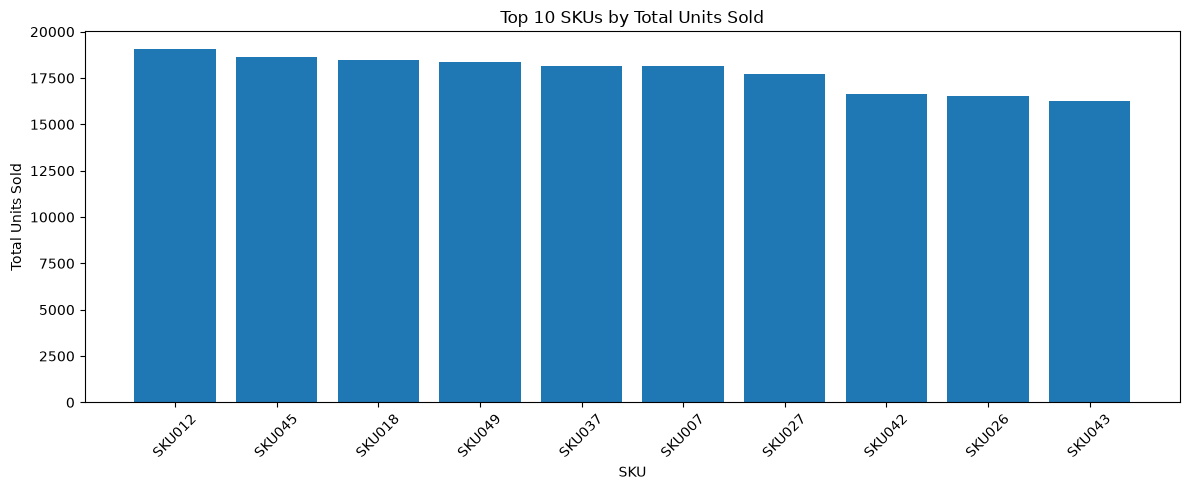

In [19]:
top10 = sku_demand.head(10)

plt.figure(figsize=(12, 5))
plt.bar(top10["SKU"], top10["Total_Units_Sold"])

plt.title("Top 10 SKUs by Total Units Sold")
plt.xlabel("SKU")
plt.ylabel("Total Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

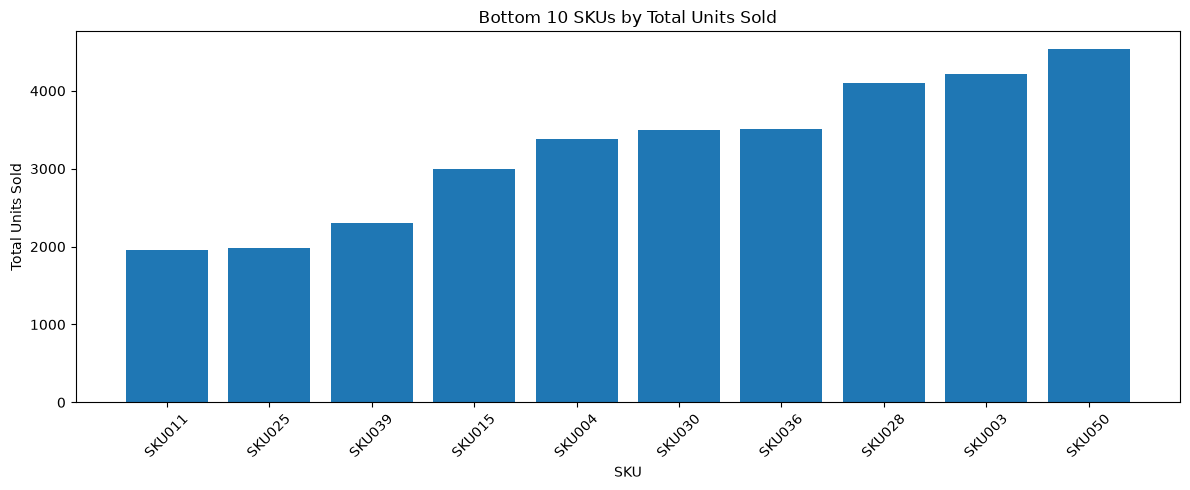

In [20]:
bottom10 = sku_demand.sort_values("Total_Units_Sold").head(10)

plt.figure(figsize=(12, 5))
plt.bar(bottom10["SKU"], bottom10["Total_Units_Sold"])

plt.title("Bottom 10 SKUs by Total Units Sold")
plt.xlabel("SKU")
plt.ylabel("Total Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
sku_demand = (
    sales.groupby("SKU")["Units_Sold"]
    .agg(["sum", "mean"])
    .reset_index()
)

sku_demand.columns = [
    "SKU",
    "Total_Units_Sold",
    "Avg_Daily_Units"
]

print("TOP 10 SKUs")
print(sku_demand.sort_values(
    "Total_Units_Sold", ascending=False
).head(10).to_string(index=False))

print("\nBOTTOM 10 SKUs")
print(sku_demand.sort_values(
    "Total_Units_Sold"
).head(10).to_string(index=False))

TOP 10 SKUs
   SKU  Total_Units_Sold  Avg_Daily_Units
SKU012             19067        26.083447
SKU045             18612        25.461012
SKU018             18450        25.239398
SKU049             18373        25.134063
SKU037             18155        24.835841
SKU007             18129        24.800274
SKU027             17717        24.236662
SKU042             16616        22.730506
SKU026             16535        22.619699
SKU043             16276        22.265390

BOTTOM 10 SKUs
   SKU  Total_Units_Sold  Avg_Daily_Units
SKU011              1951         2.668947
SKU025              1976         2.703146
SKU039              2300         3.146375
SKU015              2994         4.095759
SKU004              3380         4.623803
SKU030              3493         4.778386
SKU036              3508         4.798906
SKU028              4101         5.610123
SKU003              4214         5.764706
SKU050              4537         6.206566


In [22]:
category_demand = (
    sales.merge(
        sku[["SKU", "Category"]],
        on="SKU",
        how="left"
    )
    .groupby("Category")["Units_Sold"]
    .sum()
    .sort_values(ascending=False)
)

print(category_demand)

Category
Home Decor    132570
Lighting      102431
Kitchen       101144
Storage        93367
Furniture      82298
Name: Units_Sold, dtype: int64


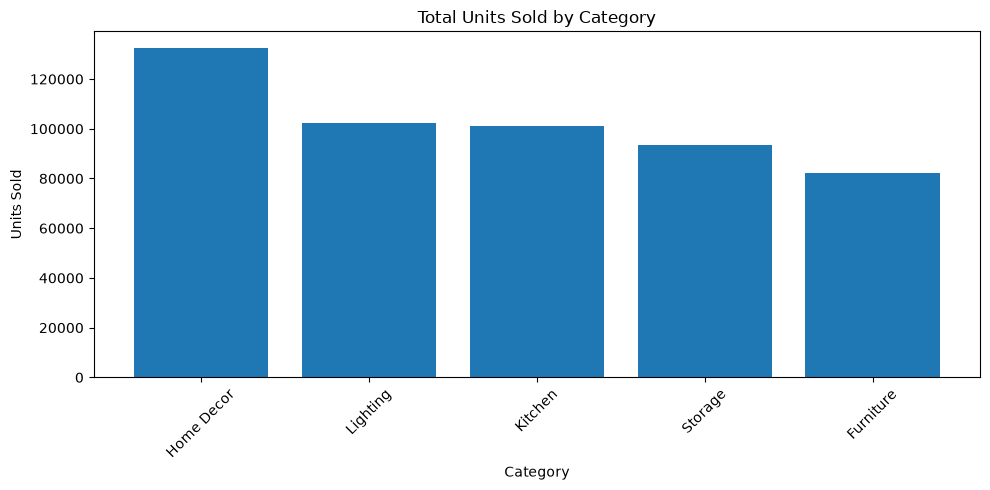

In [23]:
plt.figure(figsize=(10, 5))

plt.bar(
    category_demand.index,
    category_demand.values
)

plt.title("Total Units Sold by Category")
plt.xlabel("Category")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
promotion_demand = (
    sales.groupby("Promotion")["Units_Sold"]
    .agg(["sum", "mean"])
)

print(promotion_demand)

              sum       mean
Promotion                   
0          442011  13.475945
1           69799  18.613067


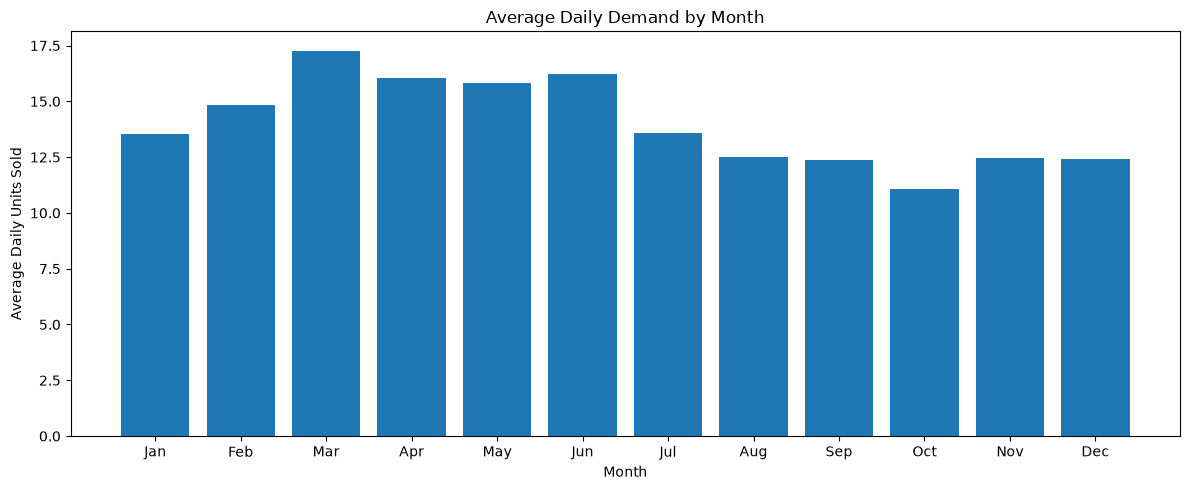

In [25]:
month_demand = (
    sales.groupby(sales["Date"].dt.month)["Units_Sold"]
    .mean()
)

month_names = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
]

plt.figure(figsize=(12, 5))

plt.bar(
    month_names,
    month_demand.values
)

plt.title("Average Daily Demand by Month")
plt.xlabel("Month")
plt.ylabel("Average Daily Units Sold")
plt.tight_layout()
plt.show()

In [26]:
weekly_sales = (
    sales.set_index("Date")
    .groupby("SKU")["Units_Sold"]
    .resample("W-MON")
    .sum()
    .reset_index()
)

weekly_sales.head()

,SKU,Date,Units_Sold
0,SKU001,2024-01-01,5
1,SKU001,2024-01-08,113
2,SKU001,2024-01-15,88
3,SKU001,2024-01-22,115
4,SKU001,2024-01-29,90


In [27]:
print("Weekly dataset shape:", weekly_sales.shape)
print("Number of SKUs:", weekly_sales["SKU"].nunique())
print("Date range:")
print(
    weekly_sales["Date"].min(),
    "to",
    weekly_sales["Date"].max()
)

Weekly dataset shape: (5300, 3)
Number of SKUs: 50
Date range:
2024-01-01 00:00:00 to 2026-01-05 00:00:00


In [28]:
weekly_sales = weekly_sales.sort_values(
    ["SKU", "Date"]
)

weekly_sales["Baseline_Forecast"] = (
    weekly_sales
    .groupby("SKU")["Units_Sold"]
    .shift(52)
)

weekly_sales.head(60)

,SKU,Date,Units_Sold,Baseline_Forecast
0,SKU001,2024-01-01,5,NaN
1,SKU001,2024-01-08,113,NaN
2,SKU001,2024-01-15,88,NaN
3,SKU001,2024-01-22,115,NaN
4,SKU001,2024-01-29,90,NaN
5,SKU001,2024-02-05,120,NaN
6,SKU001,2024-02-12,111,NaN
7,SKU001,2024-02-19,105,NaN
8,SKU001,2024-02-26,113,NaN
9,SKU001,2024-03-04,107,NaN


In [29]:
baseline_test = weekly_sales.dropna(
    subset=["Baseline_Forecast"]
).copy()

baseline_wape = (
    (baseline_test["Units_Sold"] -
     baseline_test["Baseline_Forecast"]).abs().sum()
    /
    baseline_test["Units_Sold"].abs().sum()
)

print("Seasonal-Naive WAPE:",
      round(baseline_wape * 100, 2), "%")

Seasonal-Naive WAPE: 13.29 %
